# W1D2 — Gradient Descent from Scratch — Lab

**Week 1 · Day 2 · Foundations** · Lab

This morning you ran gradient descent by hand on five points: a Riyadh flat's floor area against its
summer electricity bill. This afternoon you make the computer do it, on twenty thousand real Californian
housing blocks, and then check your answer against scikit-learn's. They must agree. You will write the
cost function, the gradient, a numerical check that proves your gradient is right, and the descent loop
itself — the same loop that trains every neural network in week 3. You leave with
`gd_history.parquet`: the path your model took, one row per iteration.

**Time budget:** ~115 minutes. Sections 1–2 are the lab; Section 3 is a stretch you may finish at home.

<div dir="rtl" align="right">

# الأسبوع ١ اليوم ٢ — النزول التدريجي من الصفر

**الأسبوع ١ · اليوم ٢ · الأساسيات** · معمل عملي

هذا الصباح نفّذت النزول التدريجي بيدك على خمس نقاط: مساحة شقة في الرياض مقابل فاتورة الكهرباء الصيفية.
بعد الظهر ستجعل الحاسوب ينفّذه، على عشرين ألف حي سكني حقيقي في كاليفورنيا، ثم تقارن إجابتك بإجابة
scikit-learn. يجب أن تتطابقا. ستكتب دالة التكلفة، والمشتقّة، وفحصًا عدديًا يثبت أن مشتقّتك صحيحة، ثم حلقة
النزول نفسها — وهي الحلقة ذاتها التي تدرّب كل شبكة عصبية في الأسبوع الثالث. وستخرج بملف
`gd_history.parquet` يسجّل مسار النموذج، صفًا لكل تكرار.

**الزمن المتوقّع:** نحو ١١٥ دقيقة. القسمان الأول والثاني هما المعمل، والقسم الثالث إضافي يمكن إكماله في المنزل.

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

By the end of this lab you can:

- Write a cost function and its gradient for a one-feature linear model, and say what each returns.
- Prove your gradient is correct with a numerical check, instead of trusting your algebra.
- Run gradient descent to a `w` and `b` that match `LinearRegression` to four decimal places.
- Explain why the raw features make the loop useless, and what standardisation changes.
- Recognise a learning rate that is too small and one that is too large from the loss curve alone.

<div dir="rtl" align="right">

## أهداف التعلّم

بنهاية هذا المعمل ستكون قادرًا على:

- كتابة دالة التكلفة ومشتقّتها لنموذج خطّي بخاصية واحدة، وتحديد ما تُرجعه كل منهما.
- إثبات صحّة المشتقّة بفحص عددي بدل الثقة في الاشتقاق اليدوي.
- تشغيل النزول التدريجي حتى الوصول إلى `w` و`b` يطابقان `LinearRegression` حتى أربع خانات عشرية.
- شرح سبب جعل الخصائص الخام للحلقة بلا فائدة، وما الذي يغيّره التوحيد القياسي.
- تمييز معدّل تعلّم صغير جدًا وآخر كبير جدًا من منحنى الخسارة وحده.

</div>

## About the data

**Dataset:** `housing_prices` — California Housing (StatLib, derived from the 1990 US census) ·
public domain · 20,640 rows

One row is a census block group — a few hundred households. Today you use **one** column of it,
`median_income` (in tens of thousands of dollars), to predict `median_house_value` (in dollars).
One feature is not a limitation here, it is the point: with one `w` and one `b` you can draw the cost
as a curve and watch the descent walk down it. Yesterday's lab used all eight columns; nothing about
the loop changes when there are eight, or eight million.

**Watch out:** `median_house_value` is capped at \$500,001 — 992 rows sit exactly on that ceiling.
You met that yesterday. Today it costs you nothing, because you are comparing your loop against
scikit-learn on the same data, cap and all; both are wrong in the same way.

**Second thing to watch:** the two columns are on wildly different scales — income runs 0.5 to 15,
price runs 15,000 to 500,001. Nothing in the setup cell fixes that for you. Section 2 is where it
bites, and where you fix it.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** `housing_prices` — بيانات مساكن كاليفورنيا (StatLib، مشتقّة من تعداد ١٩٩٠) ·
ملكية عامة · ٢٠٬٦٤٠ صفًا

الصف الواحد هو مجموعة أحياء في التعداد السكاني — بضع مئات من الأسر. اليوم تستخدم عمودًا **واحدًا** منها،
`median_income` (بعشرات آلاف الدولارات)، للتنبّؤ بـ`median_house_value` (بالدولار). الخاصية الواحدة ليست
قيدًا هنا بل هي المقصد: بمعامل `w` واحد و`b` واحد يمكنك رسم التكلفة كمنحنى ومشاهدة النزول يسير عليه.
معمل الأمس استخدم الأعمدة الثمانية جميعها، ولا يتغيّر شيء في الحلقة حين تكون الخصائص ثمانيًا أو ثمانية ملايين.

**انتبه:** عمود `median_house_value` مقصوص عند ٥٠٠٬٠٠١ دولار، وتقع ٩٩٢ صفًا على هذا السقف تمامًا. رأيت ذلك
أمس. اليوم لا يكلّفك شيئًا لأنك تقارن حلقتك بـscikit-learn على البيانات نفسها بسقفها؛ كلاهما مخطئ بالطريقة ذاتها.

**والأمر الثاني:** العمودان على مقياسين متباعدين جدًا — الدخل بين ٠٫٥ و١٥، والسعر بين ١٥٬٠٠٠ و٥٠٠٬٠٠١.
لا شيء في خلية الإعداد يعالج ذلك نيابةً عنك. القسم الثاني هو موضع الأثر، وموضع الإصلاح.

</div>

## Setup

Run the cell below first. It installs anything missing, fixes the random seed, and finds the dataset —
whether you are on your own machine or on Google Colab.

<div dir="rtl" align="right">

## الإعداد

شغّل الخلية التالية أولًا. تُثبّت ما ينقص، وتُثبّت البذرة العشوائية، وتجد ملف البيانات — سواء كنت على
جهازك أو على Google Colab.

</div>

In [2]:
# === AIEP portable setup — works locally (Miniconda + uv) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    # A clone that never ran `uv pip install -e shared/` still has the package on disk —
    # use it before reaching for the network. Colab (no clone) falls through to pip.
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, versions
from aiep.data import get_dataset, describe_dataset
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, check_close, report

ensure("scikit-learn", "matplotlib")
seed_everything(42)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aiep.viz import use_course_style
use_course_style()

DATA = get_dataset("housing_prices")
print(describe_dataset("housing_prices"))
print("\n", versions())

⬇️  Downloading housing_prices.parquet (0.81 MB) …
✅ housing_prices: downloaded to /content/aiep_data/housing_prices.parquet
housing_prices  (20640 rows, 0.81 MB)
  Source:  California Housing via sklearn.datasets.fetch_california_housing
  Licence: Public domain (StatLib, 1990 US Census derived)
  Target:  median_house_value

  EN: Housing blocks with median price as the target. The regression counterpart to telco_churn: used for the first end-to-end model (W1D1) and for gradient descent from scratch (W1D2), where a single feature keeps the arithmetic visible.
  AR: بيانات أحياء سكنية مع متوسط السعر كهدف. النظير الانحداري لمجموعة telco_churn، وتُستخدم في أول نموذج متكامل (الأسبوع ١ اليوم ١) وفي طريقة النزول التدريجي من الصفر (الأسبوع ١ اليوم ٢) حيث تُبقي خاصية واحدة الحساب مرئيًا.

  ⚠️  Watch out: The target is capped at 500001 — a wall of points at the maximum that quietly breaks the fit.
  ⚠️  انتبه: الهدف مقصوص عند القيمة ٥٠٠٠٠١، فتتكدّس نقاط كثيرة عند الحد الأقصى وتُفسد المطابقة 

## Section 1 — Warm-up: the five points, in code  (≈25 min)

Guided. The code below works. Run it, read it, then change the one parameter the task points at and
observe what moves.

These are the same five flats from this morning: `x` is floor area in hundreds of m², `y` is the summer
electricity bill in hundreds of riyals. The numbers were chosen so you could check every step by hand —
so if the computer disagrees with your notebook from this morning, one of you is wrong, and it is worth
finding out which.

As in the lecture, `b` is fixed at 0 here. It comes back in Section 2.

<div dir="rtl" align="right">

## القسم الأول — التهيئة: النقاط الخمس في شيفرة (نحو ٢٥ دقيقة)

قسم موجَّه. الشيفرة أدناه تعمل. شغّلها واقرأها، ثم غيّر المعامل الذي تشير إليه المهمة ولاحظ ما يتغيّر.

هذه هي الشقق الخمس نفسها من هذا الصباح: `x` مساحة الأرضية بمئات الأمتار المربعة، و`y` فاتورة الكهرباء
الصيفية بمئات الريالات. اختيرت الأرقام لتتمكّن من التحقّق من كل خطوة يدويًا، فإن اختلف الحاسوب مع دفترك
هذا الصباح فأحدكما مخطئ، ويستحق الأمر معرفة أيّكما.

كما في المحاضرة، قيمة `b` مثبّتة على صفر هنا، وتعود في القسم الثاني.

</div>

In [3]:
# Working code. Nothing to fill in here.
x_five = np.array([1.0, 2.0, 3.0, 4.0, 5.0])       # floor area, hundreds of m2
y_five = np.array([1.5, 3.0, 4.5, 6.0, 7.5])       # summer bill, hundreds of riyals


def predict(w, b, x):
    """The whole model: one multiplication and one addition."""
    return w * x + b


def cost(w, b, x, y):
    """Mean squared error — the average of the squared gaps."""
    return float(np.mean((predict(w, b, x) - y) ** 2))


for w in (0.0, 1.0, 2.0,3.0):
    print(f"w = {w:.1f}  ->  cost = {cost(w, 0.0, x_five, y_five):.2f}")

w = 0.0  ->  cost = 24.75
w = 1.0  ->  cost = 2.75
w = 2.0  ->  cost = 2.75
w = 3.0  ->  cost = 24.75


Those three numbers are 24.75, 2.75 and 2.75 — the ones you computed by hand this morning. The two
equal costs either side of the minimum are what told the room that the bottom sits at `w = 1.5`.

<div dir="rtl" align="right">

هذه الأرقام الثلاثة هي ٢٤٫٧٥ و٢٫٧٥ و٢٫٧٥ — نفسها التي حسبتها يدويًا هذا الصباح. والتكلفتان المتساويتان على
جانبي القاع هما ما دلّ القاعة على أن أدنى نقطة عند `w = 1.5`.

</div>

### Task 1.1 — draw the bowl

The cell below plots the cost at the three `w` values from the lecture, then the full curve behind them.
Change `w_tried` — add `1.5`, or try `[0, 3]` — re-run, and watch where the points land on the curve.

<div dir="rtl" align="right">

### المهمة ١٫١ — ارسم القاع

تَرسم الخلية أدناه التكلفة عند قيم `w` الثلاث من المحاضرة، ثم المنحنى الكامل خلفها. غيّر `w_tried` — أضف
`1.5` أو جرّب `[0, 3]` — وأعد التشغيل، ولاحظ أين تقع النقاط على المنحنى.

</div>

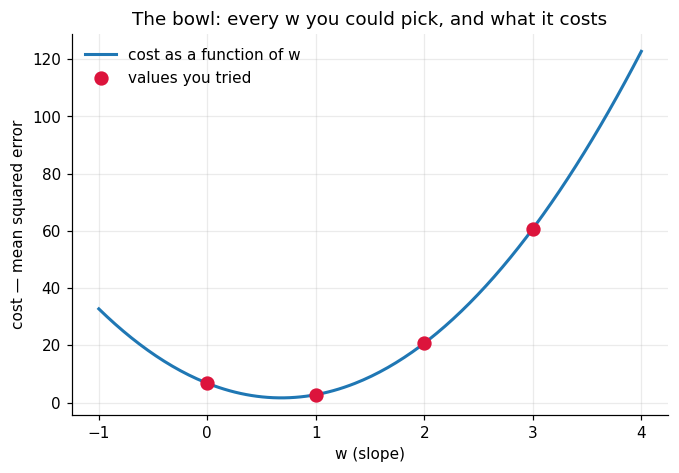

w =  0.0  ->  cost =  24.7500
w =  1.0  ->  cost =   2.7500
w =  2.0  ->  cost =   2.7500
w =  3.0  ->  cost =  24.7500


In [7]:
w_tried = [0.0, 1.0, 2.0,3.0]          # <- change this and re-run

w_grid = np.linspace(-1, 4, 200)
costs_grid = [cost(w, 3.0, x_five, y_five) for w in w_grid]

fig, ax = plt.subplots()
ax.plot(w_grid, costs_grid, linewidth=2, label="cost as a function of w")
ax.scatter(w_tried, [cost(w, 3.0, x_five, y_five) for w in w_tried],
           s=70, zorder=3, color="crimson", label="values you tried")
ax.set_xlabel("w (slope)")
ax.set_ylabel("cost — mean squared error")
ax.set_title("The bowl: every w you could pick, and what it costs")
ax.legend()
plt.show()

for w in w_tried:
    print(f"w = {w:>4.1f}  ->  cost = {cost(w, 0.0, x_five, y_five):8.4f}")

The bowl has one bottom, and gradient descent is nothing more than the rule for walking down to it
without being told where it is. Five points let you see the whole curve at once. Twenty thousand rows
and two parameters do not — which is why the rest of this lab computes the slope instead of drawing it.

<div dir="rtl" align="right">

للقاع نقطة دنيا واحدة، والنزول التدريجي ليس إلا قاعدة للسير نزولًا إليها دون أن يُقال لنا أين هي. خمس
نقاط تتيح رؤية المنحنى كاملًا دفعة واحدة، أما عشرون ألف صف ومعاملان فلا. لذلك تحسب بقية هذا المعمل
الميل بدل رسمه.

</div>

## Section 2 — Core: the loop, on real data  (≈60 min)

This is the lab. Each task below has a goal; you write the code.

From here on `b` is a real parameter, not a fixed zero, and the data is the housing file. Two
parameters, twenty thousand rows, and no picture of the bowl to guide you.

<div dir="rtl" align="right">

## القسم الثاني — الأساسي: الحلقة على بيانات حقيقية (نحو ٦٠ دقيقة)

هذا هو صلب المعمل. لكل مهمة أدناه هدف محدّد، وأنت من يكتب الشيفرة.

من هنا فصاعدًا يصبح `b` معاملًا حقيقيًا لا صفرًا مثبّتًا، وتصبح البيانات ملف المساكن. معاملان، وعشرون ألف
صف، ولا صورة للقاع تهديك.

</div>

### Task 2.1 — a cost function, and the number it returns

Write `compute_cost(w, b, x, y)` for the housing columns. It is the same formula as the warm-up; what
changes is the data underneath it.

Then read the number it gives you at `w = 0, b = 0`, and read the gradient printed under it. Both are
printed for you. Do not move on until you have looked at them — the second half of this task depends on
what you see.

<div dir="rtl" align="right">

### المهمة ٢٫١ — دالة تكلفة، والرقم الذي تُرجعه

اكتب `compute_cost(w, b, x, y)` لعمودَي المساكن. الصيغة هي نفسها من قسم التهيئة، والذي يتغيّر هو البيانات
تحتها.

ثم اقرأ الرقم الذي تُعطيه عند `w = 0, b = 0`، واقرأ المشتقّة المطبوعة تحته. كلاهما مطبوع لك. لا تنتقل قبل
أن تنظر إليهما — فالنصف الثاني من هذه المهمة يعتمد على ما ترى.

</div>

In [11]:
# ────────────────────────────────────────────────────────────────────
# 1) One row of x, one row of y, one prediction each: w * x + b.
# 2) The gap is prediction minus actual. Square every gap so the positive and the
#    negative ones stop cancelling, then take the mean of the squares.
# 3) Return a plain float, not an array — a cost is one number.
# Search: "numpy mean squared error from scratch"
# https://numpy.org/doc/stable/reference/generated/numpy.mean.html
#
# ١) لكل صف في x صف في y وتنبّؤ واحد: w * x + b.
# ٢) الفجوة هي التنبّؤ ناقص القيمة الفعلية. ربّع كل فجوة كي تتوقّف الموجبة والسالبة عن
#    إلغاء بعضهما، ثم خذ متوسّط المربّعات.
# ٣) أرجِع عددًا عشريًا مفردًا لا مصفوفة — التكلفة رقم واحد.
# ابحث عن: "numpy mean squared error from scratch"
# ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

def predict(w, b, x):
    """The whole model: one multiplication and one addition."""
    return w * x + b


def compute_cost(w, b, x, y):
    """Mean squared error — the average of the squared gaps."""
    return float(np.mean((predict(w, b, x) - y) ** 2))
df = pd.read_parquet(DATA)
x_raw = df["median_income"].to_numpy(dtype=float)
y_raw = df["median_house_value"].to_numpy(dtype=float)
# TODO: Return the mean squared error of the line (w, b) on x and y, as a single float.
# مهمة: أرجِع متوسّط مربّعات الخطأ للخط (w, b) على x وy، كعدد عشري واحد.
start_cost = compute_cost(0.0, 0.0, x_raw, y_raw)
grad_w = float(2 * np.mean(((0.0 * x_raw + 0.0) - y_raw) * x_raw))
print(f"cost at w=0, b=0 : {start_cost:,.0f}   ({start_cost:.3e})")
print(f"slope in w there : {grad_w:,.0f}")
print(f"one step at learning rate 0.01 would move w by {abs(0.01 * grad_w):,.0f}")

cost at w=0, b=0 : 56,104,831,990   (5.610e+10)
slope in w there : -1,903,022
one step at learning rate 0.01 would move w by 19,030


Look at those three numbers.

The cost is 5.6 × 10¹⁰ — not because the model is unusually bad, but because the prices are in dollars
and the errors get squared. The slope is about 1.9 million. A single step at a learning rate of 0.01
would move `w` by 19,030 — and `w` itself only needs to reach about 41,794. The loop is not walking
down the bowl; it is taking strides longer than the bowl is wide.

There is no learning rate that fixes this. Too small and `b` never moves; too large and `w` explodes.
That is not a bug in your code, it is what happens when a feature and a target live on scales that are
four orders of magnitude apart.

**The fix is to change the units, not the algorithm.** Subtract the mean and divide by the standard
deviation, for both columns. This is called **standardisation** (التوحيد القياسي), and the cell below
does it. Afterwards both columns have mean 0 and standard deviation 1, the cost at `w = 0, b = 0` is
exactly 1.0, and the slopes are small enough to walk on. Nothing about the model has changed — only the
units it is measured in. In Task 2.5 you convert the answer back into dollars and it lands on
scikit-learn's answer to the cent.

You will meet this again in W2D4, where scikit-learn does it for you and you will already know why.

<div dir="rtl" align="right">

انظر إلى الأرقام الثلاثة.

التكلفة ٥٫٦ × ١٠¹⁰ — لا لأن النموذج سيّئ بشكل استثنائي، بل لأن الأسعار بالدولار والأخطاء تُربَّع. والميل نحو
مليون وتسعمئة ألف. خطوة واحدة بمعدّل تعلّم ٠٫٠١ تحرّك `w` بمقدار ١٩٬٠٣٠، بينما `w` نفسه لا يحتاج إلا أن يبلغ
نحو ٤١٬٧٩٤. الحلقة لا تسير نزولًا في القاع، بل تخطو خطوات أطول من عرض القاع كلّه.

ولا يوجد معدّل تعلّم يصلح هنا. الصغير جدًا يجعل `b` لا يتحرّك، والكبير جدًا يفجّر `w`. هذا ليس خطأً في
شيفرتك، بل ما يحدث حين تكون الخاصية والهدف على مقياسين يفصل بينهما أربعة أسس عشرية.

**العلاج تغيير الوحدات لا تغيير الخوارزمية.** اطرح المتوسّط واقسم على الانحراف المعياري، لكلا العمودين. يُسمّى
ذلك **التوحيد القياسي** (Standardisation)، وتفعله الخلية أدناه. بعده يصبح متوسّط كل عمود صفرًا وانحرافه
المعياري واحدًا، وتصبح التكلفة عند `w = 0, b = 0` مساوية ١٫٠ تمامًا، وتصير الميول صغيرة بما يكفي للسير عليها.
لم يتغيّر شيء في النموذج، بل تغيّرت وحدات قياسه فقط. وفي المهمة ٢٫٥ تعيد الإجابة إلى الدولارات فتقع على
إجابة scikit-learn حتى السنت.

وستلتقي بهذا مجدّدًا في الأسبوع ٢ اليوم ٤، حيث تفعله scikit-learn نيابةً عنك وأنت تعرف سببه سلفًا.

</div>

In [17]:
# ────────────────────────────────────────────────────────────────────
# 1) Standardising a column means: subtract its mean, then divide by its standard deviation.
# 2) Do it to x and to y, and keep the four numbers you used — Task 2.5 needs them to
#    translate the answer back into dollars.
# 3) Check your work: the cost at w=0, b=0 on standardised data must come out at exactly 1.0.
# Search: "numpy standardise array mean std"
# https://numpy.org/doc/stable/reference/generated/numpy.std.html
#
# ١) توحيد عمود قياسيًا يعني: اطرح متوسّطه ثم اقسم على انحرافه المعياري.
# ٢) طبّق ذلك على x وعلى y، واحتفظ بالأرقام الأربعة التي استخدمتها — تحتاجها المهمة ٢٫٥
#    لإعادة الإجابة إلى الدولارات.
# ٣) تحقّق من عملك: التكلفة عند w=0, b=0 على البيانات الموحّدة يجب أن تساوي ١٫٠ تمامًا.
# ابحث عن: "numpy standardise array mean std"
# ────────────────────────────────────────────────────────────────────

# TODO: Standardise x_raw and y_raw into x and y. Keep the means and standard deviations.
# مهمة: وحّد x_raw وy_raw قياسيًا في x وy. واحتفظ بالمتوسّطات والانحرافات المعيارية.
x_mean, x_std = x_raw.mean(), x_raw.std()
y_mean, y_std = y_raw.mean(), y_raw.std()
x = (x_raw - x_mean) / x_std
y = (y_raw - y_mean) / y_std

print(f"x: mean {x.mean():.1e}, std {x.std():.4f}")
print(f"y: mean {y.mean():.1e}, std {y.std():.4f}")
print(f"cost at w=0, b=0 is now {compute_cost(0.0, 0.0, x, y):.4f}")

x: mean 6.6e-17, std 1.0000
y: mean -9.4e-17, std 1.0000
cost at w=0, b=0 is now 1.0000


### Task 2.2 — the gradient

The cost tells you how wrong the line is. The gradient tells you which way to move to make it less
wrong, and it is two numbers: one for `w` and one for `b`.

Write `compute_gradients(w, b, x, y)` returning the pair `(dw, db)`. These are the partial derivatives
of the mean squared error you saw on the board this morning.

<div dir="rtl" align="right">

### المهمة ٢٫٢ — المشتقّة

التكلفة تخبرك بمقدار خطأ الخط. والمشتقّة تخبرك بالاتجاه الذي يقلّل الخطأ، وهي رقمان: واحد لـ`w` وواحد لـ`b`.

اكتب `compute_gradients(w, b, x, y)` تُرجع الزوج `(dw, db)`. وهما المشتقّتان الجزئيتان لمتوسّط مربّعات الخطأ
اللتان رأيتهما على السبورة هذا الصباح.

</div>

In [19]:
# ────────────────────────────────────────────────────────────────────
# 1) Start from the same error term as the cost: prediction minus actual, one per row.
# 2) The derivative with respect to w weights each error by that row's x; the derivative
#    with respect to b does not — b shifts every row equally.
# 3) Both are means over the rows, and both carry the factor 2 that comes from the square.
# 4) Return them as a tuple in the order (dw, db).
# Search: "partial derivative mean squared error slope intercept"
#
# ١) ابدأ من حدّ الخطأ نفسه الذي في التكلفة: التنبّؤ ناقص الفعلي، واحد لكل صف.
# ٢) المشتقّة بالنسبة إلى w تُرجّح كل خطأ بقيمة x لذلك الصف، أما المشتقّة بالنسبة إلى b فلا
#    ترجّح — لأن b يزيح كل الصفوف بالقدر نفسه.
# ٣) كلتاهما متوسّط على الصفوف، وكلتاهما تحمل العامل ٢ الآتي من التربيع.
# ٤) أرجِعهما في زوج بالترتيب (dw, db).
# ابحث عن: "partial derivative mean squared error slope intercept"
# ────────────────────────────────────────────────────────────────────

def compute_gradients(w, b, x, y):
    """Returns (dw, db) — the slope of the cost in each parameter at the point (w, b)."""
    predictions = predict(w, b, x)
    errors = predictions - y
    dw = float(2 * np.mean(errors * x))
    db = float(2 * np.mean(errors))
    return dw, db

# TODO: Return (dw, db) — the slope of the cost in each parameter at the point (w, b).
# مهمة: أرجِع (dw, db) — ميل التكلفة في كل معامل عند النقطة (w, b).
for point in [(0.0, 0.0), (0.7, 0.1)]:
    dw_at, db_at = compute_gradients(point[0], point[1], x, y)
    print(f"at w={point[0]:.1f}, b={point[1]:.1f}  ->  dw = {dw_at:+.6f}, db = {db_at:+.6f}")

at w=0.0, b=0.0  ->  dw = -1.376150, db = +0.000000
at w=0.7, b=0.1  ->  dw = +0.023850, db = +0.200000


### Task 2.3 — prove the gradient is right

This is the most useful ten minutes of the day. Your gradient came out of algebra, and algebra has
sign errors in it. There is a way to check it that needs no algebra at all.

A derivative is a slope, and a slope is rise over run. So nudge `w` by a tiny ε, see how much the cost
moved, and divide. If your analytic gradient is correct, the two numbers agree. If you dropped the
factor of 2, or the `x`, they will not — and you will find out here, in a cell that takes a second to
run, instead of in week 3 in a network that trains for an hour and learns nothing.

Do it for `w`, then for `b`. They must agree to about four decimal places.

<div dir="rtl" align="right">

### المهمة ٢٫٣ — أثبت أن المشتقّة صحيحة

هذه أنفع عشر دقائق في اليوم. مشتقّتك خرجت من اشتقاق جبري، والاشتقاق الجبري تدخله أخطاء الإشارة. وهناك طريقة
للتحقّق لا تحتاج جبرًا إطلاقًا.

المشتقّة ميل، والميل ارتفاع على مسافة. فحرّك `w` بمقدار ε ضئيل، وانظر كم تحرّكت التكلفة، ثم اقسم. إن كانت
مشتقّتك التحليلية صحيحة تطابق الرقمان. وإن أسقطت العامل ٢ أو أسقطت `x` فلن يتطابقا — وستكتشف ذلك هنا، في
خلية تعمل في ثانية، بدل أن تكتشفه في الأسبوع الثالث داخل شبكة تتدرّب ساعة ولا تتعلّم شيئًا.

نفّذ ذلك لـ`w` ثم لـ`b`. يجب أن يتطابقا حتى نحو أربع خانات عشرية.

</div>

In [21]:
# ────────────────────────────────────────────────────────────────────
# 1) Pick any point that is not the minimum — (w, b) = (0.3, 0.1) is fine.
# 2) For w: compute the cost at w, then at w + eps with b unchanged. Rise over run is
#    (cost_after - cost_before) / eps. Use eps = 1e-6.
# 3) Repeat for b, nudging b instead and leaving w alone.
# 4) Print the analytic value, the numerical value, and the gap between them.
# Search: "numerical gradient checking finite difference"
#
# ١) اختر أي نقطة ليست النقطة الدنيا — القيمة (0.3, 0.1) مناسبة.
# ٢) لـw: احسب التكلفة عند w ثم عند w + eps مع تثبيت b. الميل هو
#    (التكلفة بعد − التكلفة قبل) / eps. استخدم eps = 1e-6.
# ٣) كرّر لـb بتحريك b وحده وترك w ثابتًا.
# ٤) اطبع القيمة التحليلية والقيمة العددية والفرق بينهما.
# ابحث عن: "numerical gradient checking finite difference"
# ────────────────────────────────────────────────────────────────────

w_test, b_test, eps = 0.3, 0.1, 1e-6

# Calculate analytic gradients
analytic_dw, analytic_db = compute_gradients(w_test, b_test, x, y)

# Calculate numerical gradients for w
cost_before_w = compute_cost(w_test, b_test, x, y)
cost_after_w = compute_cost(w_test + eps, b_test, x, y)
numeric_dw = (cost_after_w - cost_before_w) / eps

# Calculate numerical gradients for b
cost_before_b = compute_cost(w_test, b_test, x, y)
cost_after_b = compute_cost(w_test, b_test + eps, x, y)
numeric_db = (cost_after_b - cost_before_b) / eps

# TODO: Compute dw and db numerically from the cost alone, then compare both against compute_gradients.
# مهمة: احسب dw وdb عدديًا من التكلفة وحدها، ثم قارنهما بـcompute_gradients عند النقطة نفسها.
print(f"dw  analytic {analytic_dw:+.6f}   numerical {numeric_dw:+.6f}   "
      f"gap {abs(analytic_dw - numeric_dw):.2e}")
print(f"db  analytic {analytic_db:+.6f}   numerical {numeric_db:+.6f}   "
      f"gap {abs(analytic_db - numeric_db):.2e}")

dw  analytic -0.776150   numerical -0.776149   gap 1.00e-06
db  analytic +0.200000   numerical +0.200001   gap 1.00e-06


### Task 2.4 — the descent loop

Now the loop itself. Start at `w = 0, b = 0`. Two hundred times: compute the gradients, take one step
against them, and record where you are.

Record `iteration`, `w`, `b` and `cost` for every step in a list of dicts, then turn it into a
DataFrame called `history`. That DataFrame is today's artefact — it is the model's whole path, and in
Task 2.5 you plot it.

<div dir="rtl" align="right">

### المهمة ٢٫٤ — حلقة النزول

الآن الحلقة نفسها. ابدأ من `w = 0, b = 0`. ومئتَي مرة: احسب المشتقّتين، وخُذ خطوة واحدة عكسهما، وسجّل موضعك.

سجّل `iteration` و`w` و`b` و`cost` لكل خطوة في قائمة من القواميس، ثم حوّلها إلى DataFrame باسم `history`.
هذا الـDataFrame هو مخرج اليوم — فهو مسار النموذج كاملًا، وفي المهمة ٢٫٥ ترسمه.

</div>

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 1) Two parameters start at zero. Loop 200 times.
# 2) Each pass: get (dw, db) at the current point, then move each parameter AGAINST its
#    gradient by the learning rate — subtract, do not add. Adding walks up the bowl.
# 3) After moving, record the iteration number, the new w, the new b, and the new cost.
# 4) Build the DataFrame from your records at the end, not row by row inside the loop.
# Search: "pandas DataFrame from list of dicts"
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html
#
# ١) المعاملان يبدآن من الصفر. كرّر ٢٠٠ مرة.
# ٢) في كل تكرار: احسب (dw, db) عند النقطة الحالية، ثم حرّك كل معامل عكس مشتقّته بمقدار
#    معدّل التعلّم — اطرح ولا تجمع. الجمع يصعد في القاع لا ينزل.
# ٣) بعد التحريك، سجّل رقم التكرار وقيمة w الجديدة وb الجديدة والتكلفة الجديدة.
# ٤) ابنِ الـDataFrame من سجلّاتك في النهاية، لا صفًا صفًا داخل الحلقة.
# ابحث عن: "pandas DataFrame from list of dicts"
# ────────────────────────────────────────────────────────────────────

LEARNING_RATE = 0.1
N_ITERATIONS = 200
# TODO: Run 200 steps of gradient descent from (0, 0) and build `history` with one row per step.
# مهمة: نفّذ ٢٠٠ خطوة من النزول التدريجي بدءًا من (0, 0) وابنِ `history` بصف لكل خطوة.
print(history.head(3).to_string(index=False))
print("...")
print(history.tail(2).to_string(index=False))
print(f"\nfinal: w = {history['w'].iloc[-1]:.6f}, "
      f"b = {history['b'].iloc[-1]:.6f}, "
      f"cost = {history['cost'].iloc[-1]:.6f}")

### Task 2.5 — the loss curve, and the verdict

Two things here, and the second is the point of the day.

First plot `cost` against `iteration`. A healthy loss curve drops steeply and then flattens; if yours
climbs, you added the gradient instead of subtracting it.

Then check your answer. Fit `LinearRegression` on the same standardised `x` and `y` and compare its
`coef_` and `intercept_` to your final `w` and `b`. Nobody gave you the answer; you walked to it. If
the two agree, your loop is correct — and then the conversion back to dollars, which is written out for
you, must land on scikit-learn's answer on the raw columns as well.

<div dir="rtl" align="right">

### المهمة ٢٫٥ — منحنى الخسارة، والحكم

أمران هنا، والثاني هو مقصد اليوم.

أولًا ارسم `cost` مقابل `iteration`. المنحنى السليم ينخفض بحدّة ثم يستوي؛ فإن ارتفع منحناك فقد جمعت
المشتقّة بدل طرحها.

ثم تحقّق من إجابتك. درّب `LinearRegression` على `x` و`y` الموحّدين نفسيهما وقارن `coef_` و`intercept_`
بقيمتَي `w` و`b` النهائيتين لديك. لم يعطك أحد الإجابة، بل سرت إليها. فإن تطابقا فحلقتك صحيحة — وعندها
يجب أن يقع تحويل النتيجة إلى الدولارات، وهو مكتوب لك، على إجابة scikit-learn على الأعمدة الخام أيضًا.

</div>

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 1) Plot the cost column against the iteration column. Label both axes.
# 2) Fit scikit-learn's linear regression on the standardised x and y. It expects x as a
#    2-D array of one column, so reshape it.
# 3) Print sklearn's slope and intercept next to your final w and b, and the gap between them.
# Search: "sklearn LinearRegression coef_ intercept_ reshape single feature"
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
#
# ١) ارسم عمود التكلفة مقابل عمود التكرار. وسمِّ المحورين.
# ٢) درّب الانحدار الخطّي من scikit-learn على x وy الموحّدين. يتوقّع x مصفوفة ثنائية بعمود
#    واحد، فأعد تشكيلها.
# ٣) اطبع ميل scikit-learn وتقاطعه بجوار قيمتَي w وb النهائيتين لديك، والفرق بينهما.
# ابحث عن: "sklearn LinearRegression coef_ intercept_ reshape single feature"
# ────────────────────────────────────────────────────────────────────

from sklearn.linear_model import LinearRegression
w_final = float(history["w"].iloc[-1])
b_final = float(history["b"].iloc[-1])
# TODO: Plot the loss curve, then fit LinearRegression on (x, y) and compare it to (w_final, b_final).
# مهمة: ارسم منحنى الخسارة، ثم درّب LinearRegression على (x, y) وقارنه بـ(w_final, b_final).
print(f"your loop : w = {w_final:.6f}   b = {b_final:.6f}")
print(f"sklearn   : w = {sk_w:.6f}   b = {sk_b:.6f}")
print(f"difference: {abs(w_final - sk_w):.2e} in w, "
      f"{abs(b_final - sk_b):.2e} in b")
# Back to dollars. Undoing the standardisation is algebra, not insight, so it is written out:
w_dollars = w_final * y_std / x_std
b_dollars = y_mean + y_std * b_final - w_dollars * x_mean
sk_raw = LinearRegression().fit(x_raw.reshape(-1, 1), y_raw)
print(f"\nyour loop, in dollars : ${w_dollars:,.2f} per unit of income, "
      f"intercept ${b_dollars:,.2f}")
print(f"sklearn on raw columns: ${sk_raw.coef_[0]:,.2f} per unit of income, "
      f"intercept ${sk_raw.intercept_:,.2f}")

Two more numbers worth looking at.

`b` stayed at zero — not approximately, but to sixteen decimal places, from the first iteration onwards.
That is not a bug and not luck: standardising subtracted the mean from both columns, so the best line
through centred data passes through the origin. The bias had nothing left to do.

And the final cost is 0.5266, and 1 − 0.5266 = 0.4734, which is exactly
the R² you would get from `sklearn`. On standardised data the mean squared error and R² are the same
statement in different clothes. That is not a coincidence to memorise; it is a hint that the metrics you
will meet on Thursday are mostly the same quantity, rescaled.

<div dir="rtl" align="right">

رقمان آخران يستحقّان النظر.

بقي `b` صفرًا — لا تقريبًا بل حتى ستّ عشرة خانة عشرية، ومن التكرار الأول. وليس ذلك خطأً ولا صدفة: فالتوحيد
القياسي طرح المتوسّط من العمودين، ومن ثمّ يمرّ أفضل خط عبر بيانات متمركزة بنقطة الأصل، فلم يبقَ للانحياز
شيء يفعله.

والتكلفة النهائية ٠٫٥٢٦٦، و١ − ٠٫٥٢٦٦ = ٠٫٤٧٣٤، وهي بالضبط قيمة R² التي تعطيها
`sklearn`. فعلى بيانات موحّدة قياسيًا يكون متوسّط مربّعات الخطأ وR² قولًا واحدًا بثوبين. وليست هذه مصادفة
تُحفظ، بل إشارة إلى أن أغلب المقاييس التي ستلقاها يوم الخميس هي الكمية نفسها بمقياس آخر.

</div>

## Section 3 — Stretch: three learning rates  (≈30 min)

Open-ended, and lower expectation of completeness. This is where today's skill meets your capstone.

Run the same loop three times, at `0.0001`, `0.01` and `1.5`, and put all three loss curves on one
figure. One crawls, one arrives, one leaves the building. Then answer the question below — in writing,
in the cell provided.

**Link to your capstone:** every model you train from week 3 onwards has a learning rate, and the first
thing you will look at when training goes wrong is this exact plot. Learning to read it now is what
stops you from spending an evening tuning the wrong thing.

<div dir="rtl" align="right">

## القسم الثالث — الإضافي: ثلاثة معدّلات تعلّم (نحو ٣٠ دقيقة)

قسم مفتوح، ولا يُتوقّع إكماله بالكامل. هنا تلتقي مهارة اليوم بمشروع تخرّجك.

شغّل الحلقة نفسها ثلاث مرات بمعدّلات `0.0001` و`0.01` و`1.5`، وضع منحنيات الخسارة الثلاثة في شكل واحد.
واحد يزحف، وواحد يصل، وواحد يغادر تمامًا. ثم أجب عن السؤال أدناه كتابةً في الخلية المخصّصة.

**الصلة بمشروعك:** لكل نموذج تدرّبه من الأسبوع الثالث فصاعدًا معدّل تعلّم، وأول ما ستنظر إليه حين يسوء
التدريب هو هذا الرسم بعينه. وتعلّم قراءته الآن هو ما يمنعك من إضاعة أمسية في ضبط الشيء الخطأ.

</div>

In [ ]:
# ────────────────────────────────────────────────────────────────────
# 1) Wrap your loop from Task 2.4 in a function taking the learning rate as an argument
#    and returning the list of costs.
# 2) Guard it: once the cost stops being a finite number the run is over, so stop early
#    and say at which step it happened.
# 3) Plot the three curves on one axis with a log scale on y — otherwise the diverging run
#    flattens the other two into the floor.
# Search: "matplotlib semilogy multiple curves legend"
#
# ١) ضع حلقة المهمة ٢٫٤ داخل دالة تأخذ معدّل التعلّم وسيطًا
#    وتُرجع قائمة التكاليف.
# ٢) احمِها: متى توقّفت التكلفة عن كونها رقمًا منتهيًا انتهى التشغيل، فتوقّف مبكرًا واذكر
#    عند أي خطوة حدث ذلك.
# ٣) ارسم المنحنيات الثلاثة على محور واحد بمقياس لوغاريتمي على y، وإلا سحق المنحنى المتباعد
#    المنحنيين الآخرين في القاع.
# ابحث عن: "matplotlib semilogy multiple curves legend"
# ────────────────────────────────────────────────────────────────────

# TODO: Run the loop at 0.0001, 0.01 and 1.5, and put all three loss curves on one log-scale figure.
# مهمة: شغّل الحلقة بمعدّلات 0.0001 و0.01 و1.5، وضع منحنيات الخسارة الثلاثة في شكل واحد بمقياس لوغاريتمي.

Read the three numbers before you write anything.

At `0.0001` the cost is still 0.96 after two hundred steps — the loop is working, it is simply taking
two-hundredths of the step it needs. At `0.01` it reaches 0.5267 against the true minimum of 0.5266:
arrived, near enough. At `1.5` the cost after two hundred steps is about 10¹²⁰. It is not infinite yet;
it quadruples every step, so roughly three hundred steps later it would be. Either way the model is
gone, and no amount of extra training brings it back.

**Your answer:** _(write two or three sentences here — you are handed a model and a dataset you have
never seen. How would you pick a first learning rate, and what would you look at to decide whether it
was wrong?)_

<div dir="rtl" align="right">

اقرأ الأرقام الثلاثة قبل أن تكتب شيئًا.

عند `0.0001` تبقى التكلفة ٠٫٩٦ بعد مئتَي خطوة — الحلقة تعمل، لكنها تخطو جزءًا من مئتَي جزء ممّا تحتاج. وعند
`0.01` تصل إلى ٠٫٥٢٦٧ مقابل النقطة الدنيا الحقيقية ٠٫٥٢٦٦: وصلت بما يكفي. وعند `1.5` تبلغ التكلفة بعد مئتَي
خطوة نحو ١٠¹²⁰، وهي ليست لانهائية بعد، لكنها تتضاعف أربع مرات كل خطوة، فتصير كذلك بعد نحو ثلاثمئة خطوة.
وفي الحالتين ضاع النموذج، ولا يعيده أي قدر إضافي من التدريب.

**إجابتك:** _(اكتب هنا جملتين أو ثلاثًا — سُلّمت نموذجًا ومجموعة بيانات لم ترهما من قبل. كيف تختار معدّل
تعلّم أوّليًا، وما الذي تنظر إليه لتقرّر أنه خاطئ؟)_

</div>

## Save your artefact

`gd_history.parquet` is the path your model walked: one row per iteration, with `w`, `b` and the cost
at that point. Week 3 asks you to compare a hand-written loop against PyTorch's optimiser, and this file
is what you compare against.

<div dir="rtl" align="right">

## احفظ مخرجاتك

الملف `gd_history.parquet` هو المسار الذي سلكه نموذجك: صف لكل تكرار يحمل `w` و`b` والتكلفة عند تلك النقطة.
وفي الأسبوع الثالث ستقارن حلقة مكتوبة بيدك بمُحسِّن PyTorch، وهذا الملف هو ما تقارن به.

</div>

In [ ]:
out = ARTEFACT_DIR / "gd_history.parquet"
history.to_parquet(out, index=False)
print(f"Saved {out}  ({len(history)} rows)")
print(history.iloc[[0, 49, 199]].to_string(index=False))

## Sanity check

Run this last. Every check that fails tells you what to fix and why.

<div dir="rtl" align="right">

## فحص النتائج

شغّل هذه الخلية أخيرًا. كل فحص يفشل يخبرك بما يجب إصلاحه ولماذا.

</div>

In [ ]:
# --- Sanity checks ----------------------------------------------------------------
c0 = compute_cost(0.0, 0.0, x, y)

check(isinstance(c0, float) and c0 >= 0,
      f"compute_cost should return one non-negative float, got {type(c0).__name__} = {c0}",
      f"يجب أن تُرجع compute_cost عددًا عشريًا واحدًا غير سالب، والناتج {type(c0).__name__} = {c0}")

check(abs(analytic_dw - numeric_dw) < 1e-4 and abs(analytic_db - numeric_db) < 1e-4,
      f"your analytic and numerical gradients disagree by "
      f"{max(abs(analytic_dw - numeric_dw), abs(analytic_db - numeric_db)):.2e} — "
      f"they must agree to 1e-4, or the algebra in compute_gradients is wrong",
      f"المشتقّة التحليلية والعددية لديك تختلفان بمقدار "
      f"{max(abs(analytic_dw - numeric_dw), abs(analytic_db - numeric_db)):.2e} — "
      f"يجب أن تتطابقا حتى 1e-4، وإلا ففي اشتقاق compute_gradients خطأ")

first_50 = history["cost"].to_numpy()[:50]
check(bool(np.all(np.diff(first_50) <= 0) and first_50[9] < first_50[0]),
      f"the cost must never rise over the first 50 iterations, and must have fallen visibly by the "
      f"tenth ({first_50[0]:.4f} -> {first_50[9]:.4f}) — if it rises, you are adding the gradient "
      f"instead of subtracting it",
      f"يجب ألا ترتفع التكلفة في أي من التكرارات الخمسين الأولى، وأن تكون قد انخفضت بوضوح عند "
      f"العاشر ({first_50[0]:.4f} ← {first_50[9]:.4f}) — فإن ارتفعت فأنت تجمع المشتقّة بدل طرحها")

check(len(history) == N_ITERATIONS,
      f"the history should have one row per iteration ({N_ITERATIONS}), got {len(history)}",
      f"يجب أن يحتوي السجلّ صفًا لكل تكرار ({N_ITERATIONS})، والعدد الحالي {len(history)}")

check_close(w_final, sk_w,
            "your final w should match scikit-learn's slope",
            "يجب أن يطابق w النهائي لديك ميل scikit-learn",
            tol=0.01)

check(abs(w_dollars - float(sk_raw.coef_[0])) < 1.0,
      f"converted back to dollars your slope should match scikit-learn on the raw columns to within "
      f"$1, got ${w_dollars:,.2f} vs ${sk_raw.coef_[0]:,.2f}",
      f"بعد التحويل إلى الدولارات يجب أن يطابق ميلك ميل scikit-learn على الأعمدة الخام بفارق أقل من "
      f"دولار، والقيمتان ${w_dollars:,.2f} و${sk_raw.coef_[0]:,.2f}")

check((ARTEFACT_DIR / "gd_history.parquet").exists(),
      "gd_history.parquet should exist — run the save cell above",
      "يجب أن يوجد الملف gd_history.parquet — شغّل خلية الحفظ أعلاه")

report()

## What's next

Tomorrow the output stops being a price and becomes a probability: logistic regression on customer
churn, fitted by the same descent you just wrote.

<div dir="rtl" align="right">

## ماذا بعد

غدًا يتوقّف المخرج عن كونه سعرًا ويصير احتمالًا: الانحدار اللوجستي (Logistic Regression) على مغادرة
العملاء، مُدرَّبًا بالنزول نفسه الذي كتبته للتو.

</div>